## Imports

In [240]:
import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)

from pathlib import Path

import joblib
import warnings

warnings.filterwarnings("ignore")

## Configuration

In [241]:
DB_PATH = "../gridsight.duckdb"

TRAIN_END_DATE = "2025-12-31 23:00:00"
TEST_START_DATE = "2026-01-01 00:00:00"
TEST_END_DATE = "2026-06-30 23:00:00"

TARGET = "solar_generation_mw"

RANDOM_STATE = 42

EXPERIMENTS_DIR = Path("../experiments")
MODELS_DIR = Path("../models")

EXPERIMENTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

## Load Gold Dataset

In [242]:
with duckdb.connect(DB_PATH) as con:
    df = con.sql("""
        SELECT *
        FROM gold_training_dataset
        ORDER BY timestamp
    """).df()

## Exploratory Checks

In [243]:
df.shape

(30000, 41)

In [244]:
df.info

<bound method DataFrame.info of                 timestamp  solar_generation_mw  temperature_c  \
0     2023-01-08 00:00:00             2.207500          5.572   
1     2023-01-08 01:00:00             2.052500          5.336   
2     2023-01-08 02:00:00             1.962500          5.596   
3     2023-01-08 03:00:00             2.322500          5.260   
4     2023-01-08 04:00:00             2.310000          5.216   
...                   ...                  ...            ...   
29995 2026-06-30 16:00:00         12288.627500         24.156   
29996 2026-06-30 17:00:00          5923.406750         23.940   
29997 2026-06-30 18:00:00          1910.517250         23.440   
29998 2026-06-30 19:00:00           173.456500         23.008   
29999 2026-06-30 20:00:00             1.293667         21.592   

       relative_humidity_pct  precipitation_mm  cloud_cover_pct  \
0                      81.16             0.040            94.56   
1                      80.92             0.004       

In [245]:
df.isnull().sum()

timestamp                                  0
solar_generation_mw                        0
temperature_c                              0
relative_humidity_pct                      0
precipitation_mm                           0
cloud_cover_pct                            0
wind_speed_kmh                             0
shortwave_radiation                        0
direct_radiation                           0
diffuse_radiation                          0
direct_normal_irradiance                   0
hour                                       0
month                                      0
day_of_week                                0
day_of_year                                0
is_weekend                                 0
year                                       0
solar_generation_mw_lag_1h                 0
solar_generation_mw_lag_24h                0
solar_generation_mw_lag_168h               0
solar_generation_mw_roll_mean_3h           0
solar_generation_mw_roll_mean_6h           0
solar_gene

In [246]:
df.duplicated().sum()

np.int64(0)

In [247]:
df["timestamp"] - df["timestamp"].shift(1) == pd.Timedelta(hours=1)


0        False
1         True
2         True
3         True
4         True
         ...  
29995     True
29996     True
29997     True
29998     True
29999     True
Name: timestamp, Length: 30000, dtype: bool

In [248]:
df['solar_generation_mw'].max()


np.float64(55982.79275)

In [249]:
df['solar_generation_mw'].min()

np.float64(0.0)

In [250]:
df['solar_generation_mw'].mean()

np.float64(7849.080086525271)

In [251]:
df['solar_generation_mw'].median()

np.float64(383.363607)

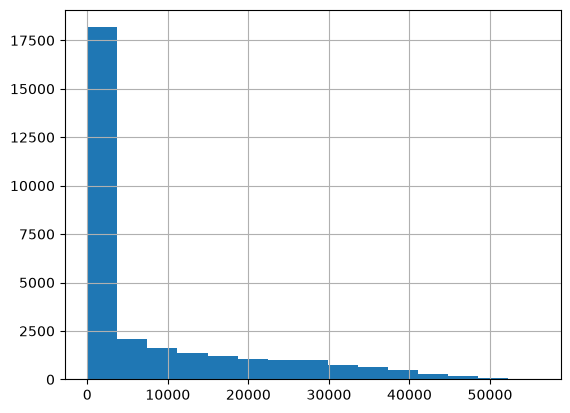

In [252]:
df['solar_generation_mw'].hist(bins=15)
plt.show()

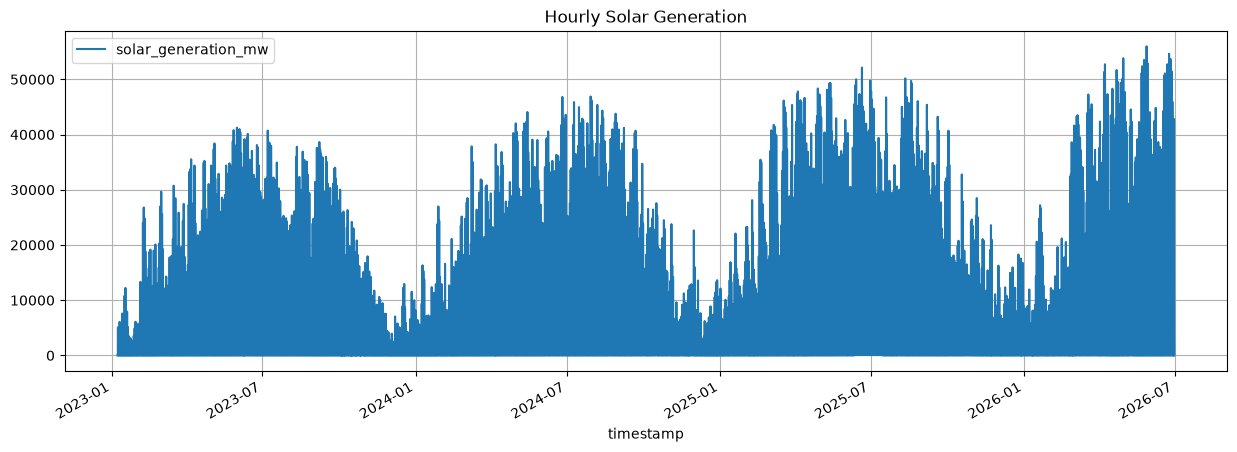

In [253]:
df.plot(
    x="timestamp",
    y="solar_generation_mw",
    figsize=(15, 5),
    title="Hourly Solar Generation",
    grid=True
)

plt.show()

In [254]:
avg_generation_by_month = df.groupby(['month', 'year'])['solar_generation_mw'].mean()
avg_generation_by_month

month  year
1      2023     1037.439711
       2024     1927.099839
       2025     2187.442751
       2026     2200.045423
2      2023     3436.731820
       2024     3213.945974
       2025     4492.036918
       2026     3773.612889
3      2023     5020.407110
       2024     6554.810582
       2025     9282.675763
       2026     9814.099640
4      2023     7669.596990
       2024     9200.544843
       2025    12431.988881
       2026    17462.531874
5      2023    10778.360843
       2024    11564.151894
       2025    13732.730122
       2026    18949.341847
6      2023    12367.746876
       2024    12271.682769
       2025    14633.600595
       2026    19443.846180
7      2023    10341.223761
       2024    12509.172496
       2025    12172.427479
8      2023     8786.979270
       2024    12017.581519
       2025    13000.363339
9      2023     9109.168652
       2024     8557.409748
       2025     8938.750064
10     2023     4449.117595
       2024     4787.031650
       2

## Train/Test Split

In [255]:
train_df = df[df['timestamp'] < TEST_START_DATE]
train_df

,timestamp,solar_generation_mw,temperature_c,relative_humidity_pct,precipitation_mm,cloud_cover_pct,wind_speed_kmh,shortwave_radiation,direct_radiation,diffuse_radiation,...,solar_generation_mw_roll_max_24h,daylight_duration_hours,sunshine_duration_hours,is_daylight,minutes_since_sunrise,daylight_progress_pct,cloud_shortwave_interaction,temperature_shortwave_interaction,wind_temperature_interaction,daylight_progress_shortwave_interaction
0,2023-01-08 00:00:00,2.207500,5.572,81.16,0.040,94.56,19.008,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,105.912576,0.0
1,2023-01-08 01:00:00,2.052500,5.336,80.92,0.004,89.76,19.436,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,103.710496,0.0
2,2023-01-08 02:00:00,1.962500,5.596,82.72,0.008,93.88,19.540,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,109.345840,0.0
3,2023-01-08 03:00:00,2.322500,5.260,83.48,0.084,94.12,19.656,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,103.390560,0.0
4,2023-01-08 04:00:00,2.310000,5.216,83.40,0.100,89.72,19.308,0.0,0.0,0.0,...,9617.947500,8.154408,2.315869,0,0,0.0,0.0,0.0,100.710528,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26131,2025-12-31 19:00:00,16.194653,-0.380,84.84,0.084,79.84,16.532,0.0,0.0,0.0,...,9107.519598,7.972042,0.000000,0,579,1.0,0.0,-0.0,-6.282160,0.0
26132,2025-12-31 20:00:00,12.068738,-0.412,86.56,0.096,83.88,15.920,0.0,0.0,0.0,...,9107.519598,7.972042,0.000000,0,639,1.0,0.0,-0.0,-6.559040,0.0
26133,2025-12-31 21:00:00,13.948841,-0.472,87.32,0.072,80.84,16.024,0.0,0.0,0.0,...,9107.519598,7.972042,0.000000,0,699,1.0,0.0,-0.0,-7.563328,0.0
26134,2025-12-31 22:00:00,12.549746,-0.528,87.88,0.052,83.60,16.384,0.0,0.0,0.0,...,9107.519598,7.972042,0.000000,0,759,1.0,0.0,-0.0,-8.650752,0.0


In [256]:
train_df["timestamp"].min()

Timestamp('2023-01-08 00:00:00')

In [257]:
train_df["timestamp"].max()

Timestamp('2025-12-31 23:00:00')

In [258]:
test_df = df[df['timestamp'] >= TEST_START_DATE]
test_df

,timestamp,solar_generation_mw,temperature_c,relative_humidity_pct,precipitation_mm,cloud_cover_pct,wind_speed_kmh,shortwave_radiation,direct_radiation,diffuse_radiation,...,solar_generation_mw_roll_max_24h,daylight_duration_hours,sunshine_duration_hours,is_daylight,minutes_since_sunrise,daylight_progress_pct,cloud_shortwave_interaction,temperature_shortwave_interaction,wind_temperature_interaction,daylight_progress_shortwave_interaction
26136,2026-01-01 00:00:00,15.137830,-0.568,87.12,0.048,83.36,17.780,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-10.099040,0.000000
26137,2026-01-01 01:00:00,15.056636,-0.504,86.52,0.036,84.36,18.340,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-9.243360,0.000000
26138,2026-01-01 02:00:00,16.133698,-0.584,86.04,0.076,79.88,18.592,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-10.857728,0.000000
26139,2026-01-01 03:00:00,12.625848,-0.556,86.32,0.088,83.28,20.048,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-11.146688,0.000000
26140,2026-01-01 04:00:00,12.553904,-0.576,85.76,0.024,82.20,20.524,0.00,0.00,0.00,...,9107.519598,7.989436,0.000000,0,0,0.000000,0.0000,-0.00000,-11.821824,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2026-06-30 16:00:00,12288.627500,24.156,53.84,0.092,70.72,8.232,615.72,412.08,203.64,...,42819.561250,16.504208,15.619033,1,654,0.660438,43543.7184,14873.33232,198.852192,406.644649
29996,2026-06-30 17:00:00,5923.406750,23.940,54.28,0.064,73.36,8.340,499.72,306.48,193.24,...,42819.561250,16.504208,15.619033,1,714,0.721028,36659.4592,11963.29680,199.659600,360.312223
29997,2026-06-30 18:00:00,1910.517250,23.440,56.96,0.280,71.40,8.860,364.12,196.20,167.92,...,42819.561250,16.504208,15.619033,1,774,0.781619,25998.1680,8534.97280,207.678400,284.603048
29998,2026-06-30 19:00:00,173.456500,23.008,59.20,0.052,67.16,8.240,249.68,122.96,126.72,...,42819.561250,16.504208,15.619033,1,834,0.842209,16768.5088,5744.63744,189.585920,210.282852


In [259]:
test_df["timestamp"].min()

Timestamp('2026-01-01 00:00:00')

In [260]:
test_df["timestamp"].max()

Timestamp('2026-06-30 20:00:00')

## Features

### v0 Features

In [261]:
v0_features = [
    "solar_generation_mw_lag_1h",
    "solar_generation_mw_lag_24h",
    "solar_generation_mw_lag_168h"
]

### v1 Features

In [262]:
v1_features = v0_features + [
    "temperature_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "cloud_cover_pct",
    "wind_speed_kmh",
    
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "direct_normal_irradiance"
]

### v2 Features

In [263]:
v2_features = v1_features + [
  "hour",
  "month",
  "day_of_week",
  "day_of_year",
  "is_weekend",
  "year"
]

### v3 Features

In [264]:
v3_features = v2_features + [
  "daylight_duration_hours",
  "sunshine_duration_hours",
  "is_daylight",
  "minutes_since_sunrise",
  "daylight_progress_pct",
]

### v4 Features

In [265]:
v4_features = v3_features + [
  "solar_generation_mw_roll_mean_3h",
  "solar_generation_mw_roll_mean_6h",
  "solar_generation_mw_roll_mean_24h",
  
  "solar_generation_mw_roll_std_3h",
  "solar_generation_mw_roll_std_6h",
  "solar_generation_mw_roll_std_24h",
  
  "solar_generation_mw_roll_min_3h",
  "solar_generation_mw_roll_min_6h",
  "solar_generation_mw_roll_min_24h",
  
  "solar_generation_mw_roll_max_3h",
  "solar_generation_mw_roll_max_6h",
  "solar_generation_mw_roll_max_24h"
]

### v5 Features

In [266]:
v5_features = v4_features + [
  "cloud_shortwave_interaction",
  "temperature_shortwave_interaction",
  "wind_temperature_interaction",
  "daylight_progress_shortwave_interaction"
]

In [267]:
feature_versions = {
  "V0": v0_features,
  "V1": v1_features,
  "V2": v2_features,
  "V3": v3_features,
  "V4": v4_features,
  "V5": v5_features
}

## Train Models

In [268]:
models = {
    "Linear Regression": LinearRegression(),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE),
    "LightGBM": LGBMRegressor(random_state=RANDOM_STATE)
}

In [269]:
experiment_results = []
for version, features in feature_versions.items():
  
  X_train = train_df[features]
  y_train = train_df[TARGET]
  
  
  X_test = test_df[features]
  y_test = test_df[TARGET]
  
  for name, model in models.items():
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    # Evaluate Models
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    wape = (abs(y_test - predictions).sum() / y_test.sum()) * 100
    
    # Logging Experiments
    
    experiment_results.append({
    "Version": version,
    "Model": name,
    "Features": len(features),
    "MAE": mae,
    "RMSE": rmse,
    "WAPE": wape
})

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values("WAPE")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 26136, number of used features: 3
[LightGBM] [Info] Start training from score 7355.741747
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3059
[LightGBM] [Info] Number of data points in the train set: 26136, number of used features: 12
[LightGBM] [Info] Start training from score 7355.741747
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

## Log Experiments

In [270]:
results_df

,Version,Model,Features,MAE,RMSE,WAPE
15,V5,Linear Regression,39,929.776702,1328.396000,8.311961
12,V4,Linear Regression,35,1004.586364,1436.455436,8.980740
9,V3,Linear Regression,23,2632.545541,3724.975960,23.534271
7,V2,XGBoost,18,2732.743055,5611.070808,24.430011
8,V2,LightGBM,18,2795.025801,5610.176930,24.986802
6,V2,Linear Regression,18,2936.515282,4255.728313,26.251681
11,V3,LightGBM,23,2973.787396,5838.256757,26.584884
3,V1,Linear Regression,12,2992.669236,4327.481001,26.753683
10,V3,XGBoost,23,3063.503896,6534.972607,27.386927
16,V5,XGBoost,39,3089.559131,6380.041753,27.619854


## Visualising Results

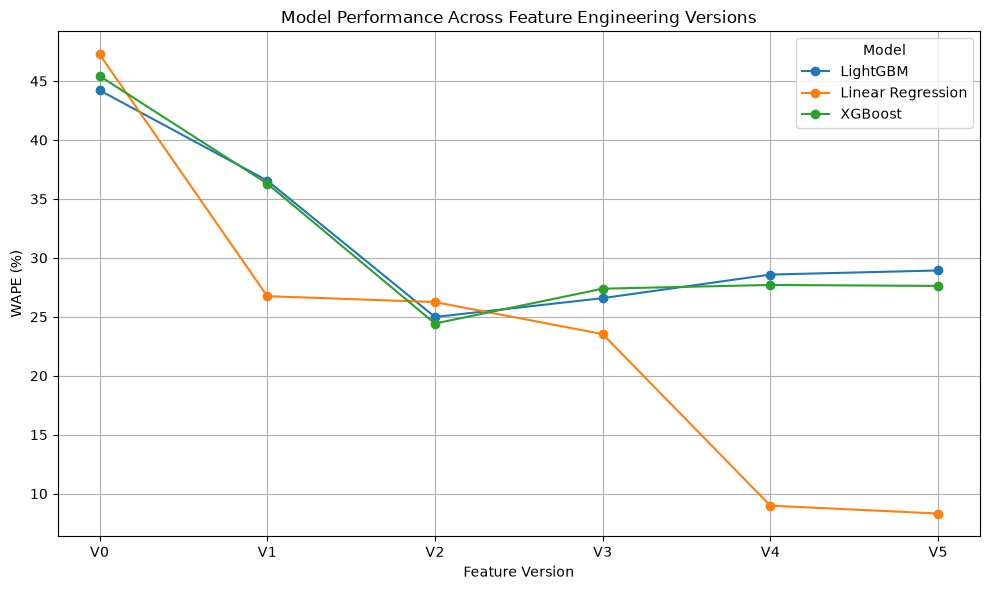

In [271]:
pivot = results_df.pivot(
    index="Version",
    columns="Model",
    values="WAPE"
)

pivot.plot(
    figsize=(10, 6),
    marker="o"
)

plt.title("Model Performance Across Feature Engineering Versions")
plt.xlabel("Feature Version")
plt.ylabel("WAPE (%)")
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()

plt.show()

## Saving Result

In [ ]:
results_df.to_csv(
    "../reports/experiment_results.csv",
    index=False
)

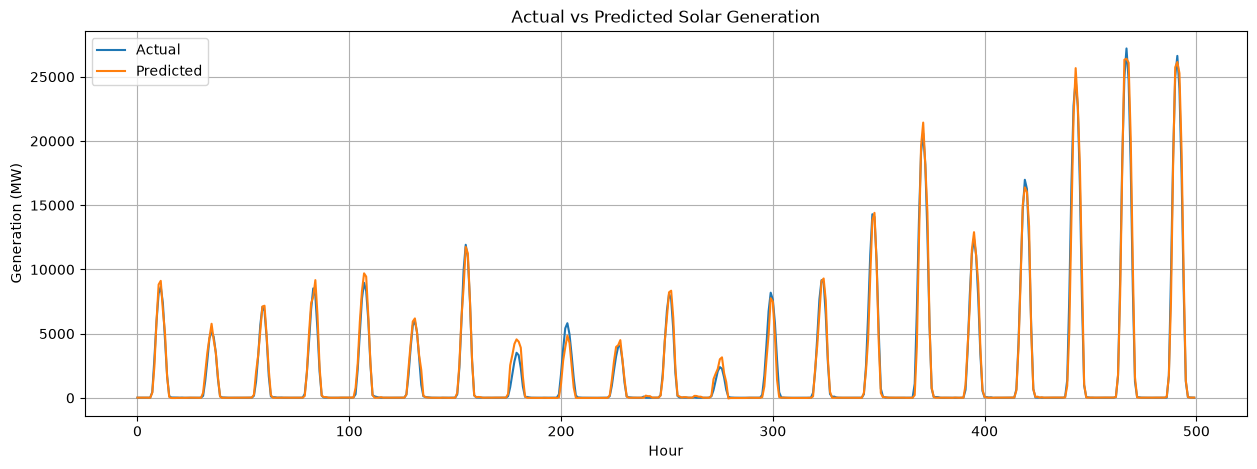

In [273]:
plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:500], label="Actual")
plt.plot(predictions[:500], label="Predicted")

plt.title("Actual vs Predicted Solar Generation")
plt.xlabel("Hour")
plt.ylabel("Generation (MW)")
plt.legend()
plt.grid(True)

plt.show()
